<a href="https://colab.research.google.com/github/Nawshin-25/Geo_Analysis/blob/Practice/SST_of_SMI(90_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y libproj-dev proj-data proj-bin
!apt-get install -y libgeos-dev
!pip install cartopy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libproj-dev is already the newest version (9.1.1-1~jammy0).
libproj-dev set to manually installed.
proj-data is already the newest version (9.1.1-1~jammy0).
proj-data set to manually installed.
The following NEW packages will be installed:
  proj-bin
0 upgraded, 1 newly installed, 0 to remove and 30 not upgraded.
Need to get 197 kB of archives.
After this operation, 504 kB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 proj-bin amd64 9.1.1-1~jammy0 [197 kB]
Fetched 197 kB in 2s (127 kB/s)
Selecting previously unselected package proj-bin.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../proj-bin_9.1.1-1~jammy0_amd64.deb ...
Unpacking proj-bin (9.1.1-1~jammy0) ...
Setting up proj-bin (9.1.1-1~jammy0) ...
Processing triggers for man-db (2.10.2-1) ...
Reading package lists... Don

In [ ]:
!pip install gsw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy.stats import linregress
import geopandas as gpd
import cartopy.crs as ccrs

In [ ]:
file_name = '/content/drive/MyDrive/Data/SMI/SST_SMI.nc'
ds = xr.open_dataset(file_name)
print (ds)
temperature = ds['sst']

<xarray.Dataset> Size: 2MB
Dimensions:     (valid_time: 12875, latitude: 5, longitude: 7)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 103kB 1990-01-01 ... 2025-04-01
  * latitude    (latitude) float64 40B 21.0 20.75 20.5 20.25 20.0
  * longitude   (longitude) float64 56B 91.0 91.25 91.5 91.75 92.0 92.25 92.5
    expver      (valid_time) <U4 206kB ...
Data variables:
    sst         (valid_time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-06T15:05 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
saint_martins_shape = gpd.read_file('/content/drive/MyDrive/Data/2021/Total_area_2021.shp')
mpa_border_shape = gpd.read_file('/content/drive/MyDrive/Data/2021/Saint_Martin MPA.shp')

# **Winter**

<ipython-input-7-2bbe0591462a>:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


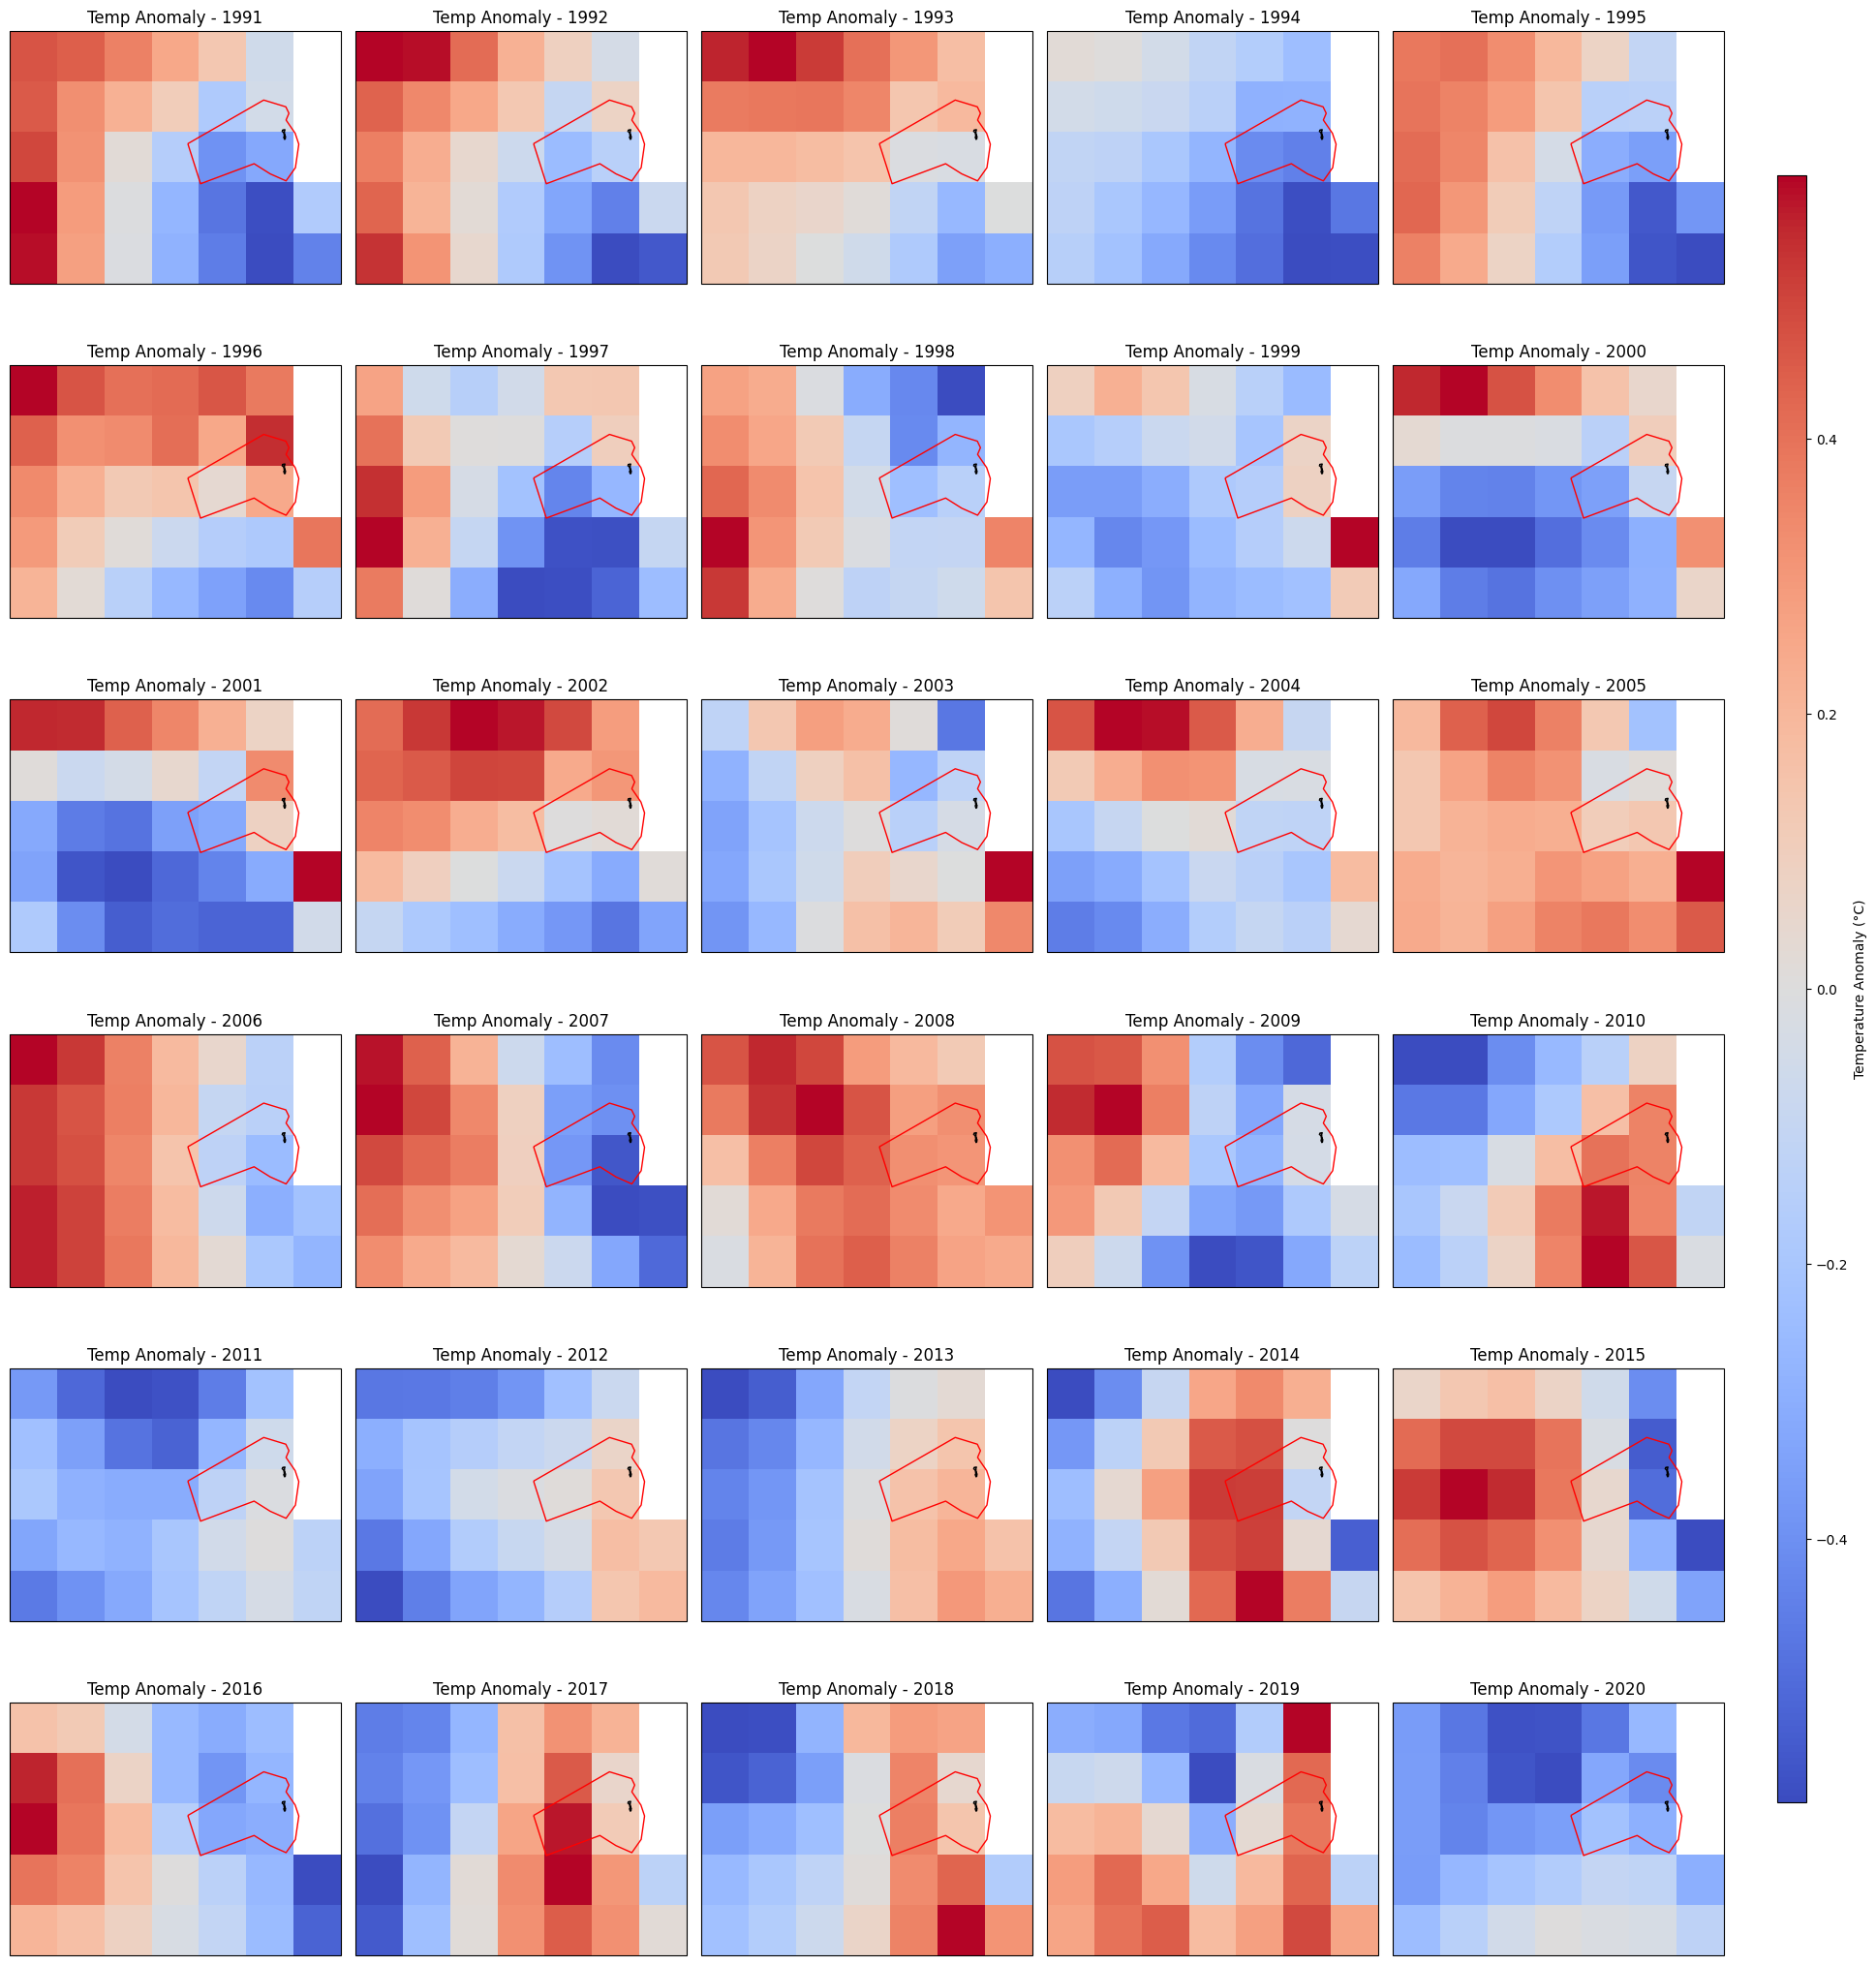

In [ ]:
temperature_celsius = temperature - 273.15
temperature_winter = temperature_celsius.sel(
    valid_time=((temperature_celsius['valid_time.year'] >= 1990) &
                (temperature_celsius['valid_time.year'] <= 2025) &
                ((temperature_celsius['valid_time.month'] == 1) |
                 (temperature_celsius['valid_time.month'] == 11) |
                 (temperature_celsius['valid_time.month'] == 12)))
)

# Compute anomalies
temperature_anomaly = temperature_winter - temperature_winter.mean(dim='valid_time')
temperature_anomaly_mean = temperature_anomaly.groupby('valid_time.year').mean(dim='valid_time')

years = list(range(1991, 2021))
n_years = len(years)
ncols = 5
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3.5), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'coolwarm'

# Flatten axes in case of single row or column
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    data = temperature_anomaly_mean.sel(year=year)

    # Plot SST anomaly
    temp_plot = data.plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=False
    )

    # Overlay shapefiles
    saint_martins_shape.boundary.plot(ax=ax, color='black', linewidth=1)
    mpa_border_shape.boundary.plot(ax=ax, color='red', linewidth=1)

    ax.set_title(f'Temp Anomaly - {year}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
fig.colorbar(temp_plot, cax=cbar_ax, label='Temperature Anomaly (°C)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# **Premonsoon**

<ipython-input-8-58776a7ffbca>:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


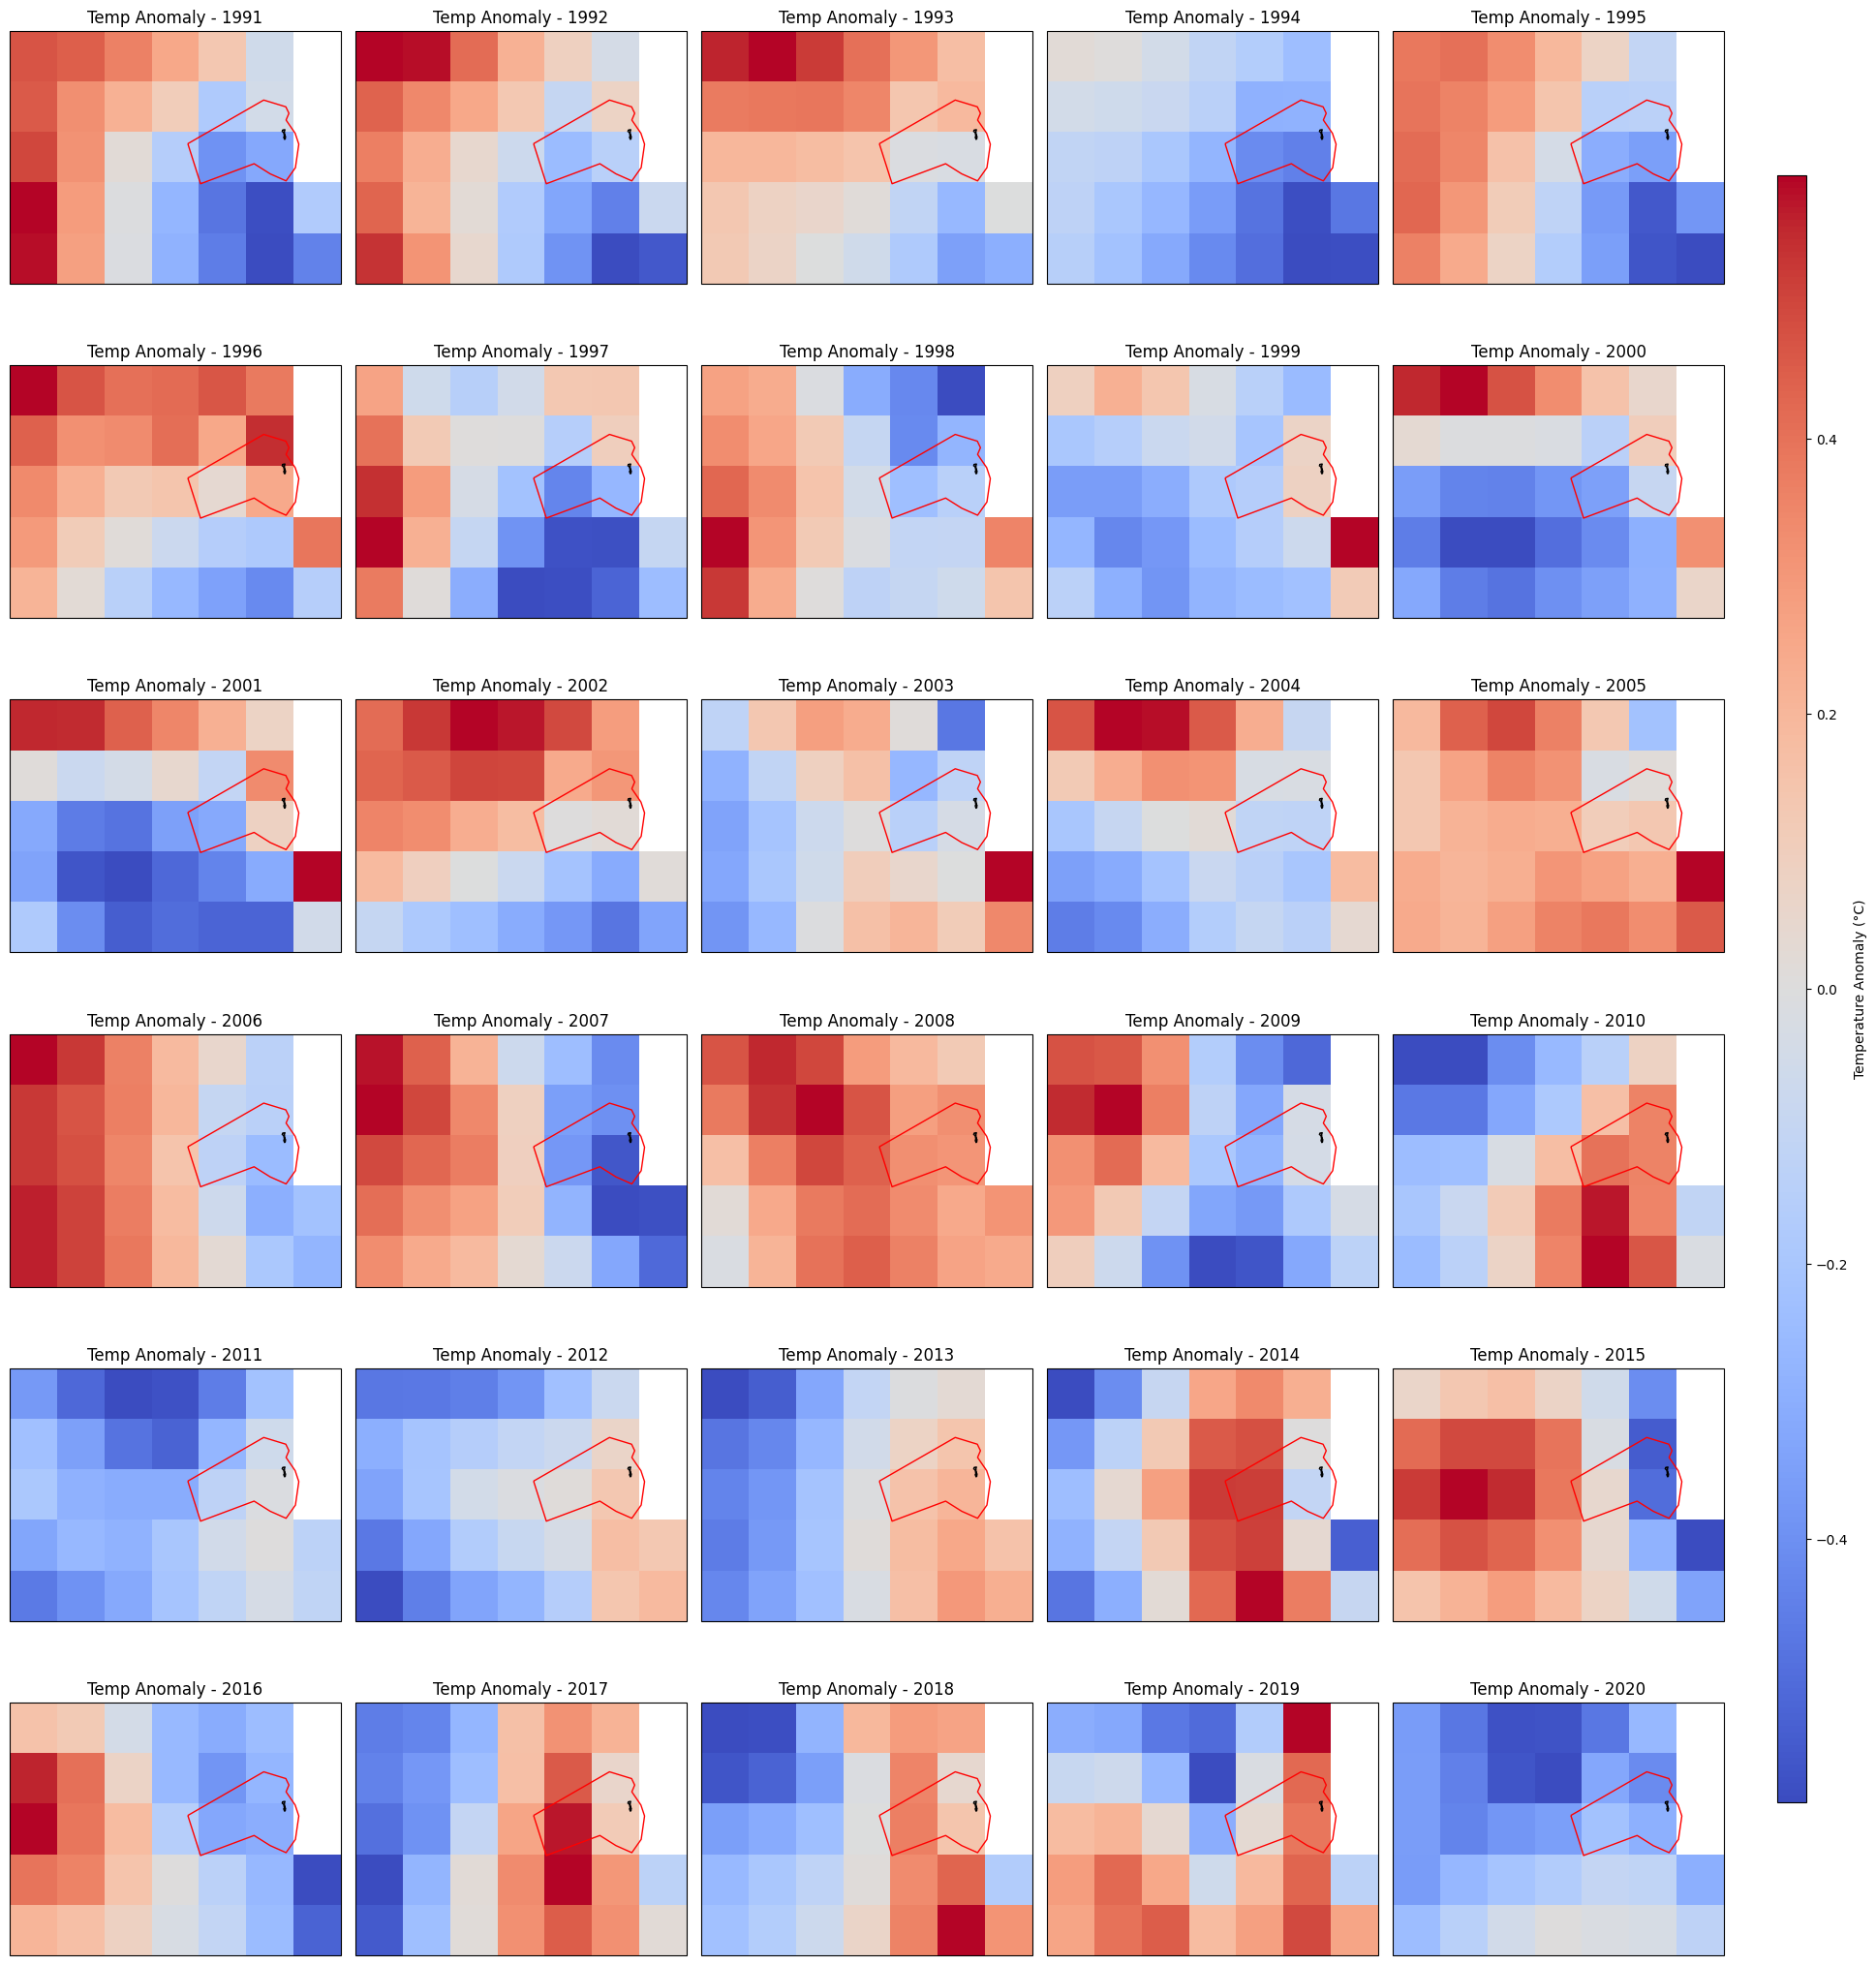

In [ ]:
temperature_celsius = temperature - 273.15
temperature_premonsoon = temperature_celsius.sel(
    valid_time=((temperature_celsius['valid_time.year'] >= 1990) &
                (temperature_celsius['valid_time.year'] <= 2025) &
                ((temperature_celsius['valid_time.month'] == 2) |
                 (temperature_celsius['valid_time.month'] == 3) |
                 (temperature_celsius['valid_time.month'] == 4)))
)

# Compute anomalies
temperature_anomaly = temperature_winter - temperature_winter.mean(dim='valid_time')
temperature_anomaly_mean = temperature_anomaly.groupby('valid_time.year').mean(dim='valid_time')

years = list(range(1991, 2021))
n_years = len(years)
ncols = 5
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3.5), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'coolwarm'

# Flatten axes in case of single row or column
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    data = temperature_anomaly_mean.sel(year=year)

    # Plot SST anomaly
    temp_plot = data.plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=False
    )

    # Overlay shapefiles
    saint_martins_shape.boundary.plot(ax=ax, color='black', linewidth=1)
    mpa_border_shape.boundary.plot(ax=ax, color='red', linewidth=1)

    ax.set_title(f'Temp Anomaly - {year}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
fig.colorbar(temp_plot, cax=cbar_ax, label='Temperature Anomaly (°C)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# **Monsoon**

<ipython-input-9-e8fb0a7e9170>:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


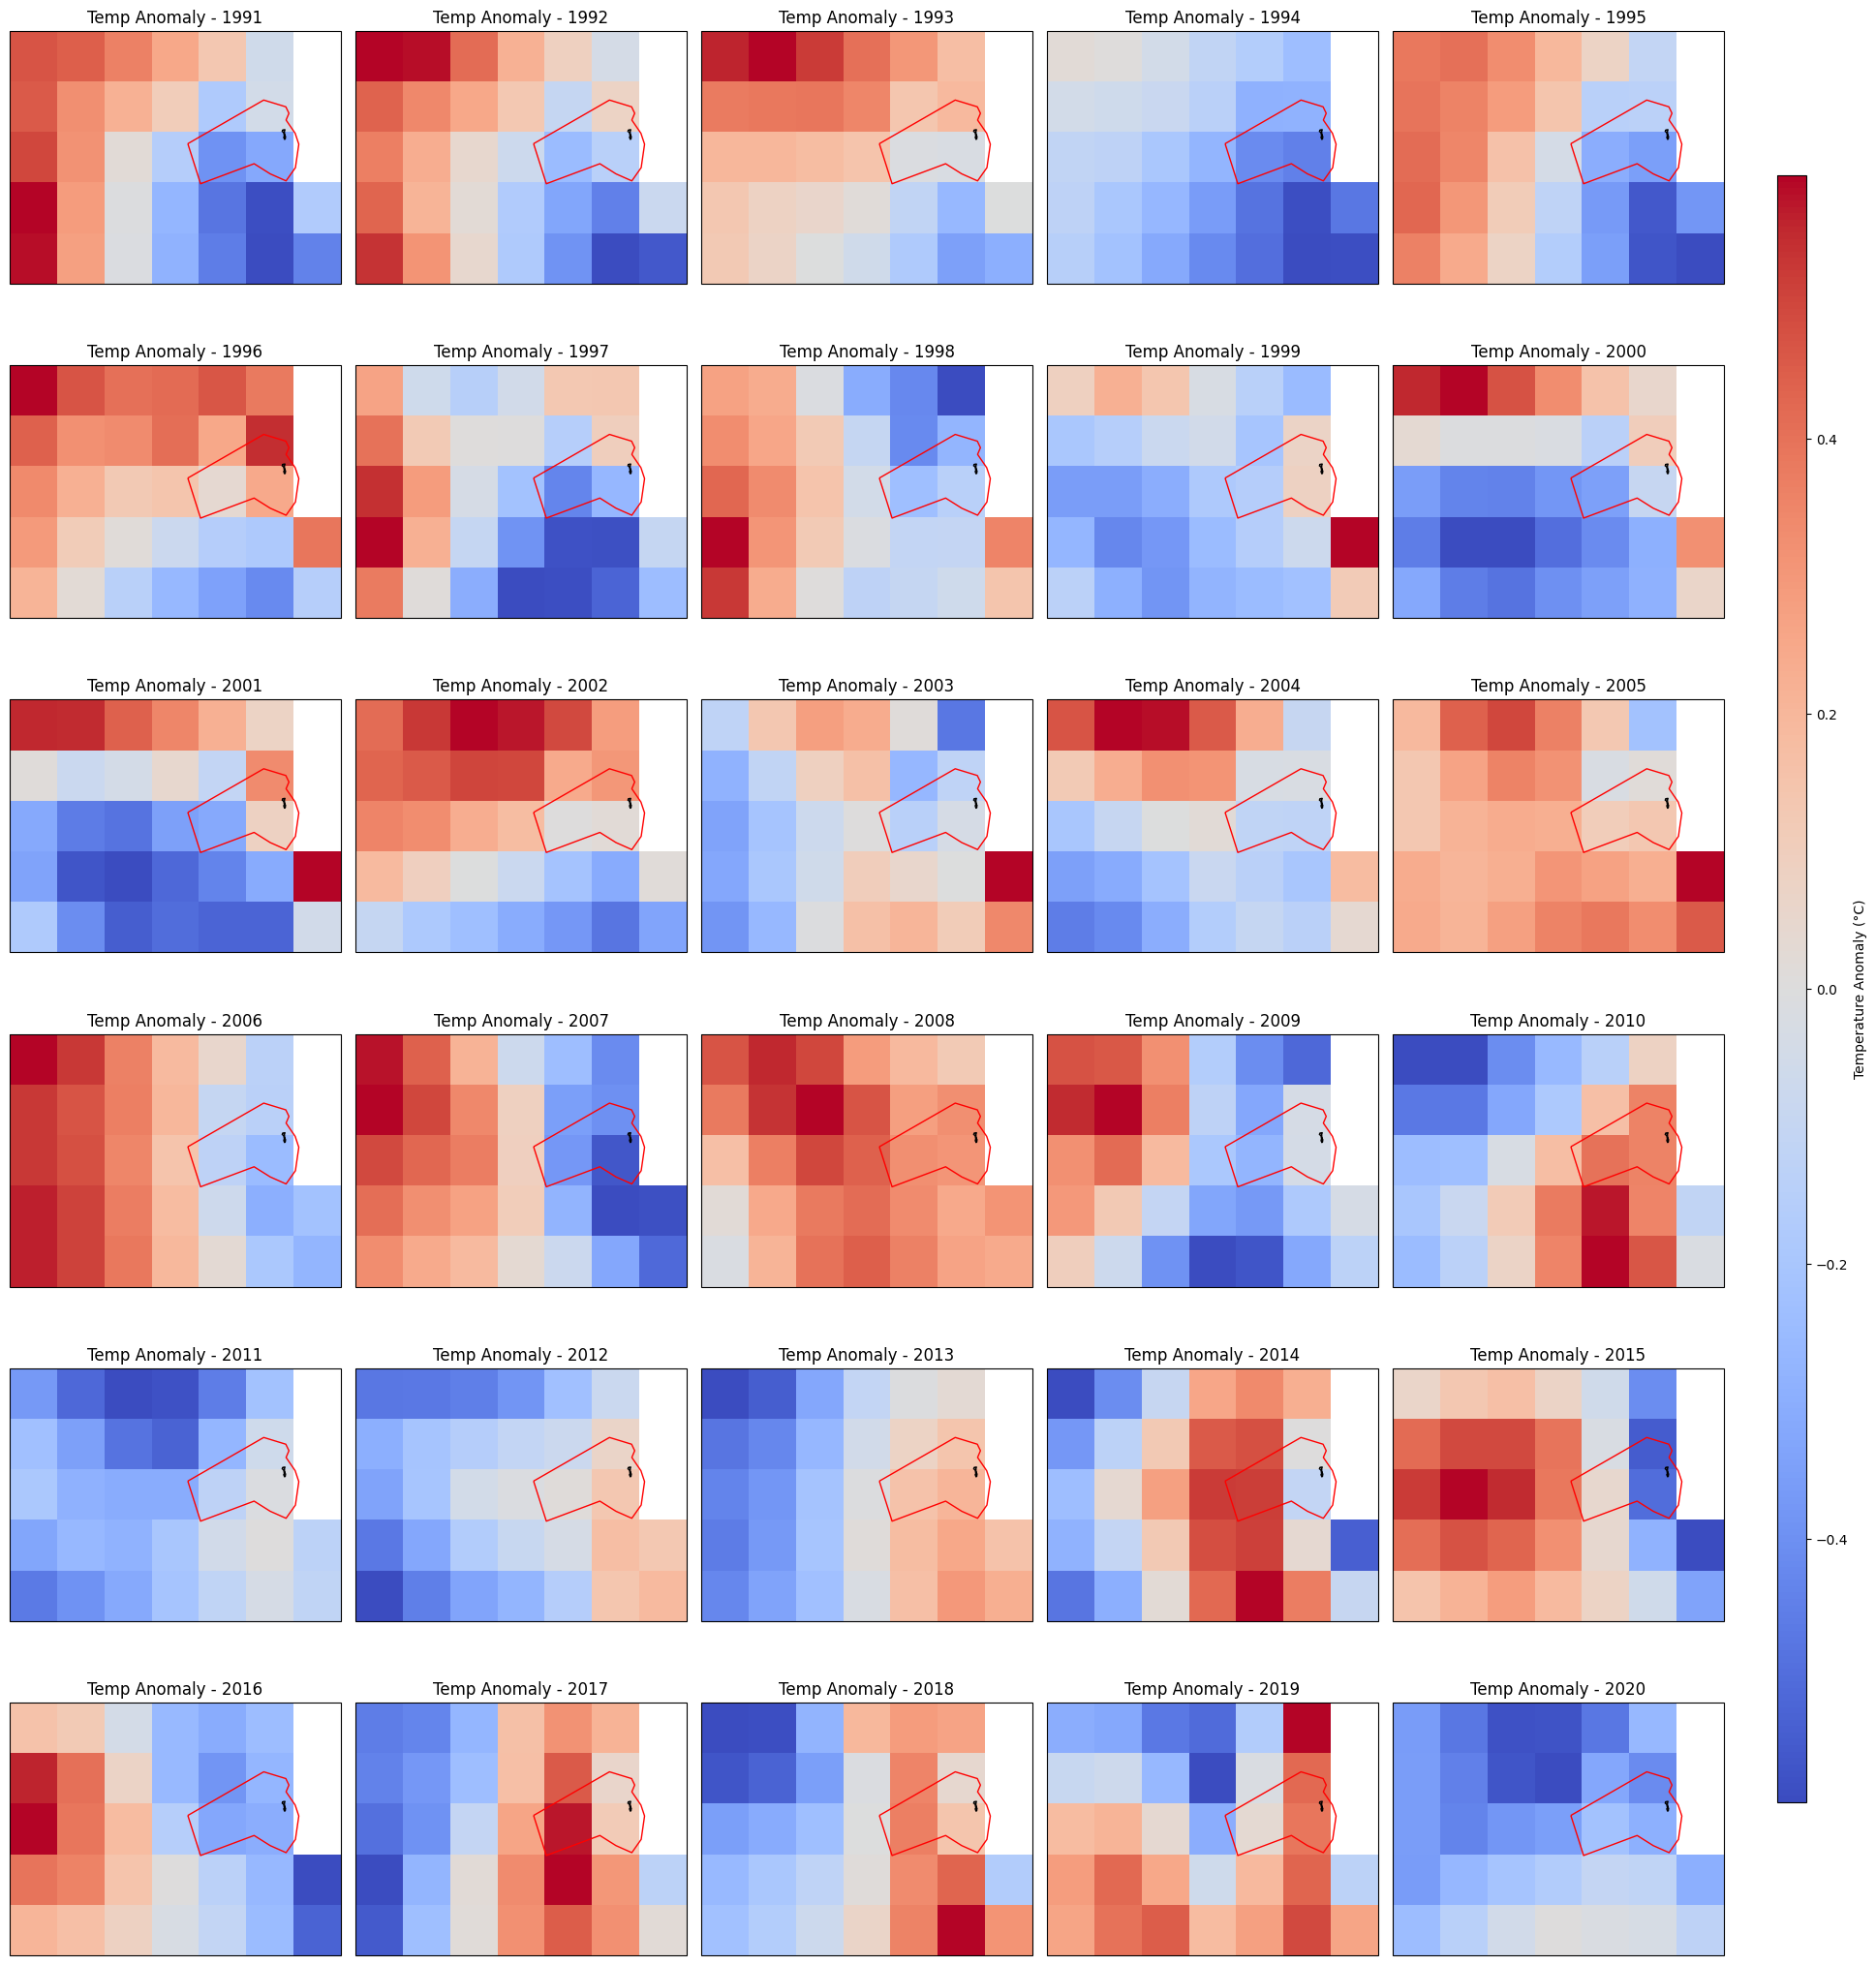

In [ ]:
temperature_celsius = temperature - 273.15
temperature_premonsoon = temperature_celsius.sel(
    valid_time=((temperature_celsius['valid_time.year'] >= 1990) &
                (temperature_celsius['valid_time.year'] <= 2025) &
                ((temperature_celsius['valid_time.month'] == 5) |
                 (temperature_celsius['valid_time.month'] == 6) |
                 (temperature_celsius['valid_time.month'] == 7)))
)

# Compute anomalies
temperature_anomaly = temperature_winter - temperature_winter.mean(dim='valid_time')
temperature_anomaly_mean = temperature_anomaly.groupby('valid_time.year').mean(dim='valid_time')

years = list(range(1991, 2021))
n_years = len(years)
ncols = 5
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3.5), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'coolwarm'

# Flatten axes in case of single row or column
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    data = temperature_anomaly_mean.sel(year=year)

    # Plot SST anomaly
    temp_plot = data.plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=False
    )

    # Overlay shapefiles
    saint_martins_shape.boundary.plot(ax=ax, color='black', linewidth=1)
    mpa_border_shape.boundary.plot(ax=ax, color='red', linewidth=1)

    ax.set_title(f'Temp Anomaly - {year}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
fig.colorbar(temp_plot, cax=cbar_ax, label='Temperature Anomaly (°C)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# **Postmonsoon**

<ipython-input-10-3f9a29ce7415>:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


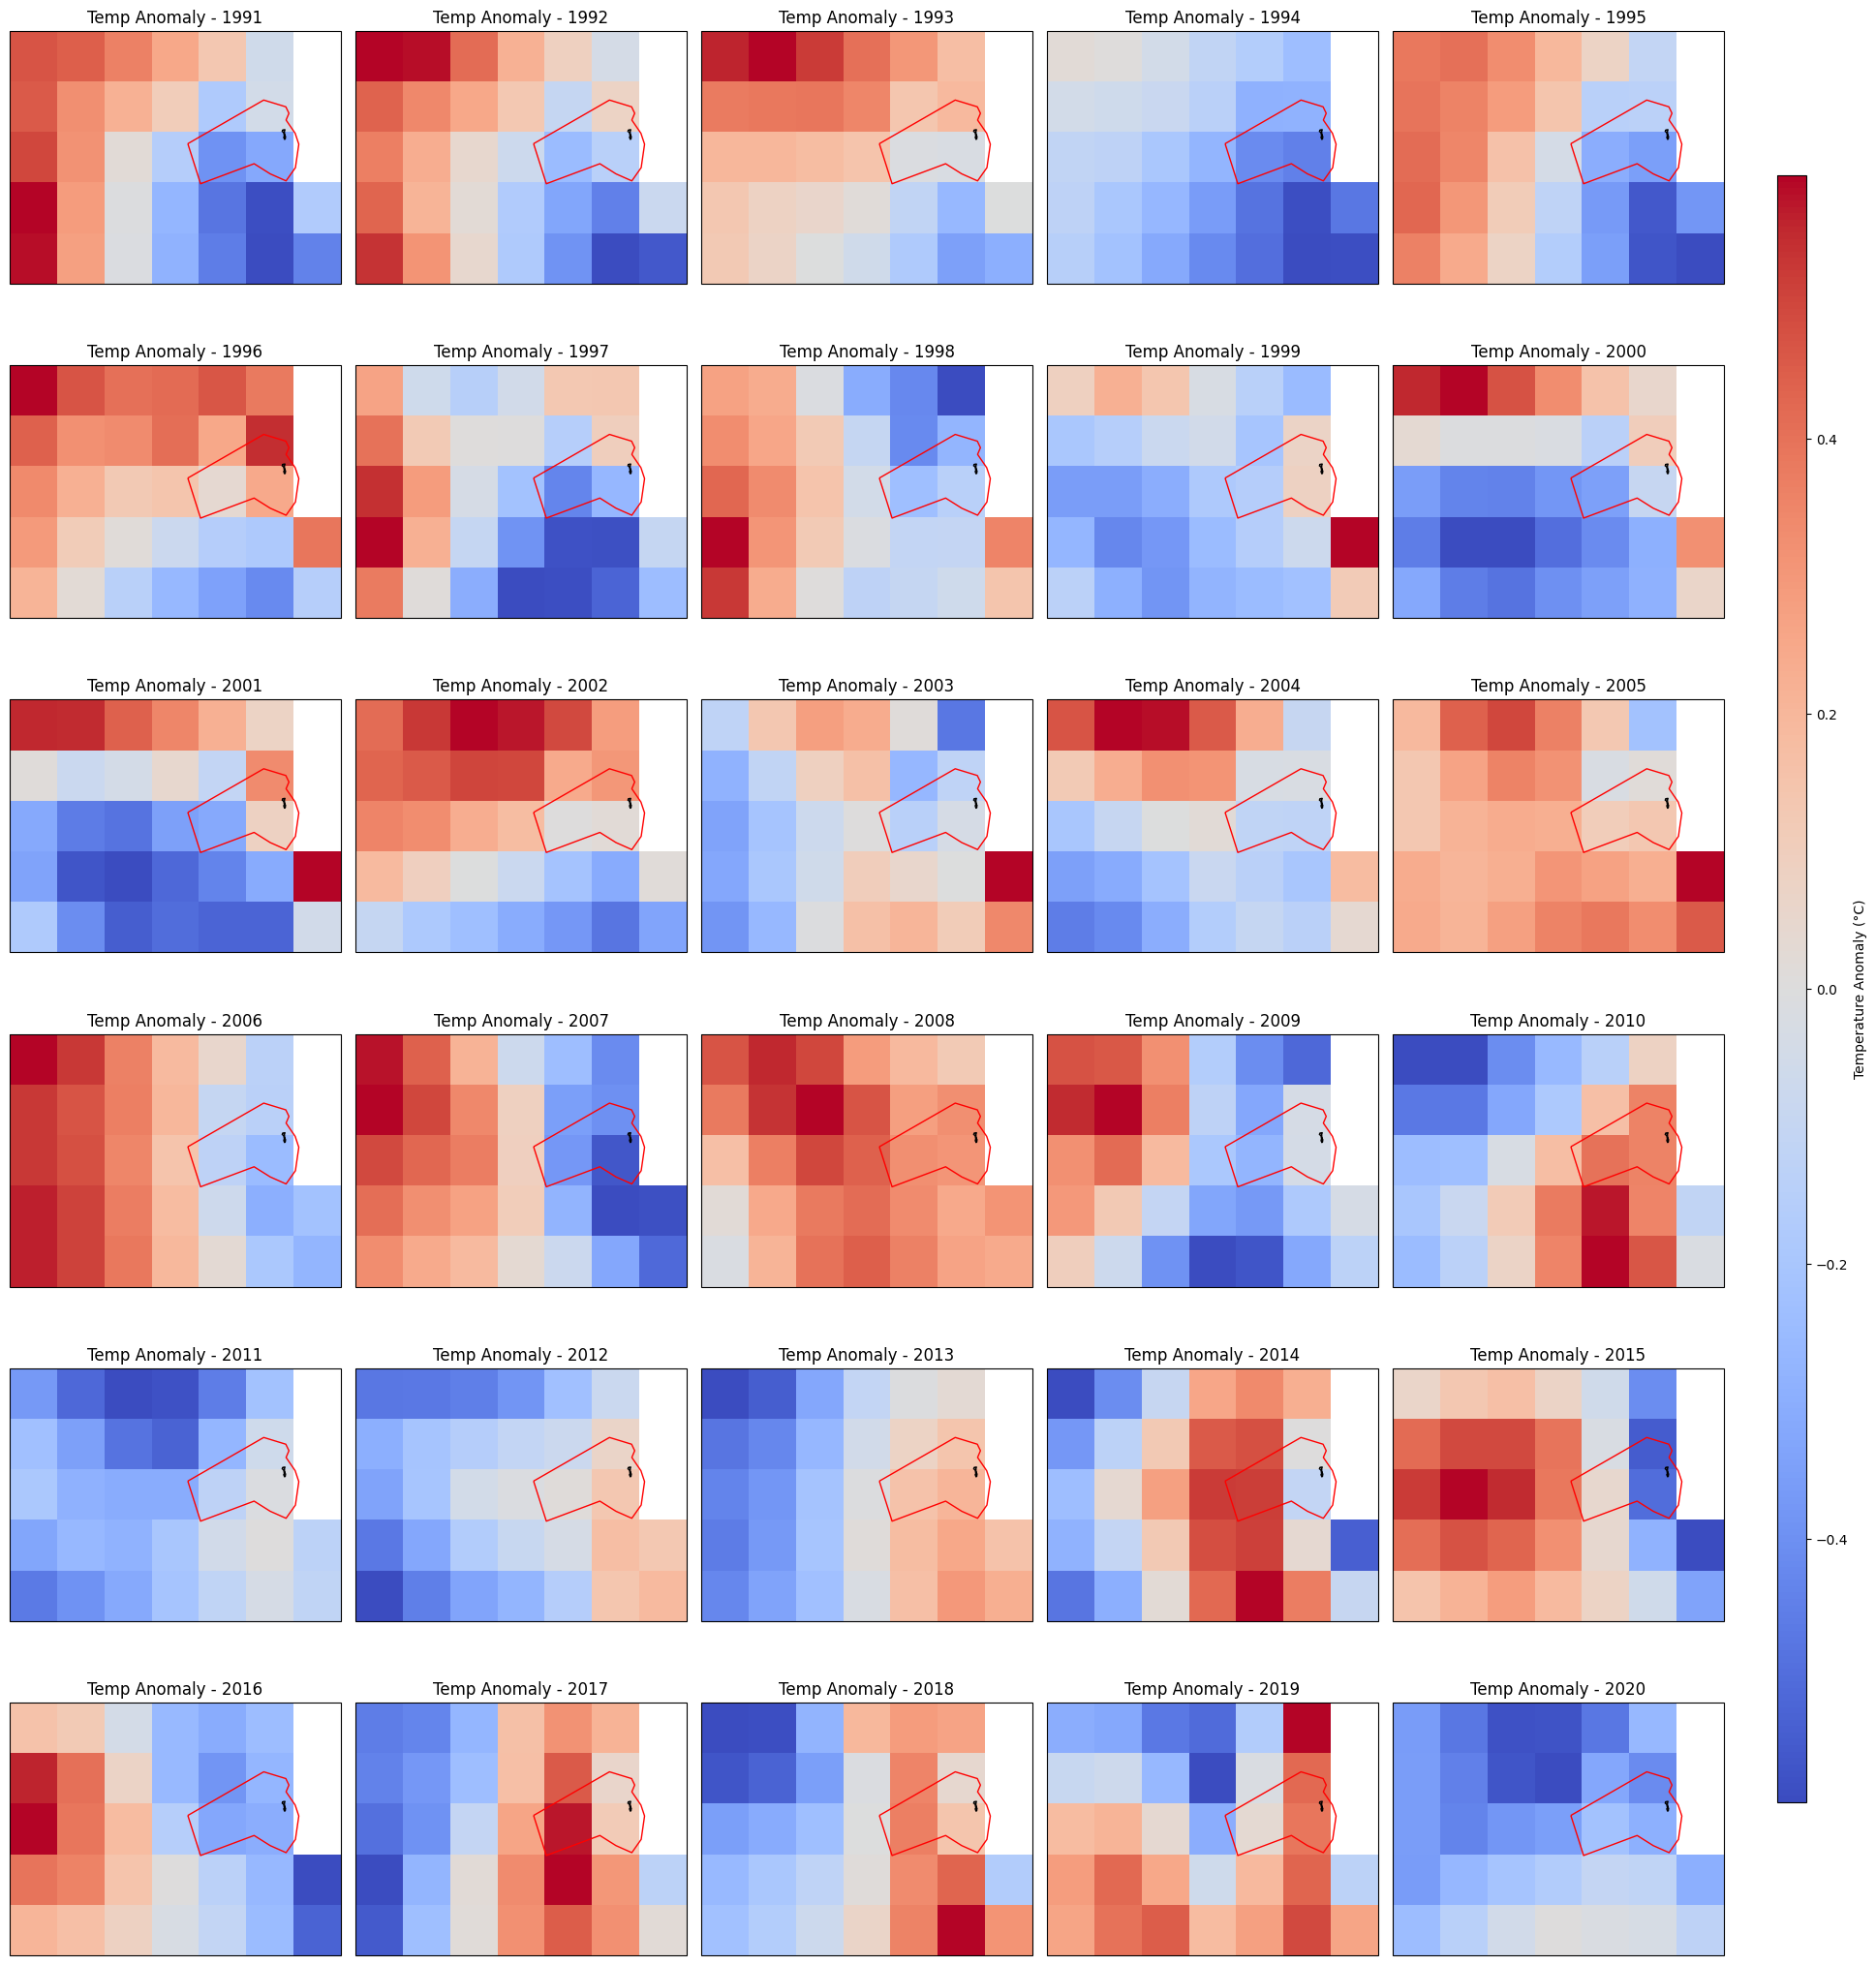

In [ ]:
temperature_celsius = temperature - 273.15
temperature_premonsoon = temperature_celsius.sel(
    valid_time=((temperature_celsius['valid_time.year'] >= 1990) &
                (temperature_celsius['valid_time.year'] <= 2025) &
                ((temperature_celsius['valid_time.month'] == 8) |
                 (temperature_celsius['valid_time.month'] == 9) |
                 (temperature_celsius['valid_time.month'] == 10)))
)

# Compute anomalies
temperature_anomaly = temperature_winter - temperature_winter.mean(dim='valid_time')
temperature_anomaly_mean = temperature_anomaly.groupby('valid_time.year').mean(dim='valid_time')

years = list(range(1991, 2021))
n_years = len(years)
ncols = 5
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 3.5), subplot_kw={'projection': ccrs.PlateCarree()})
cmap = 'coolwarm'

# Flatten axes in case of single row or column
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    data = temperature_anomaly_mean.sel(year=year)

    # Plot SST anomaly
    temp_plot = data.plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=False
    )

    # Overlay shapefiles
    saint_martins_shape.boundary.plot(ax=ax, color='black', linewidth=1)
    mpa_border_shape.boundary.plot(ax=ax, color='red', linewidth=1)

    ax.set_title(f'Temp Anomaly - {year}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.8])
fig.colorbar(temp_plot, cax=cbar_ax, label='Temperature Anomaly (°C)')

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Anomaly

In [ ]:
time_filtered = ds.valid_time.sel(valid_time=slice('1991-01-01', '2020-12-31'))
lat_idx = 0  # Select the first latitude index
lon_idx = 0  # Select the first longitude index
depth_idx = 0  # Select the first depth index (surface)

Total SST Anomaly (°C) from 1991-01-01 to 2020-12-31: -96.2059 °C


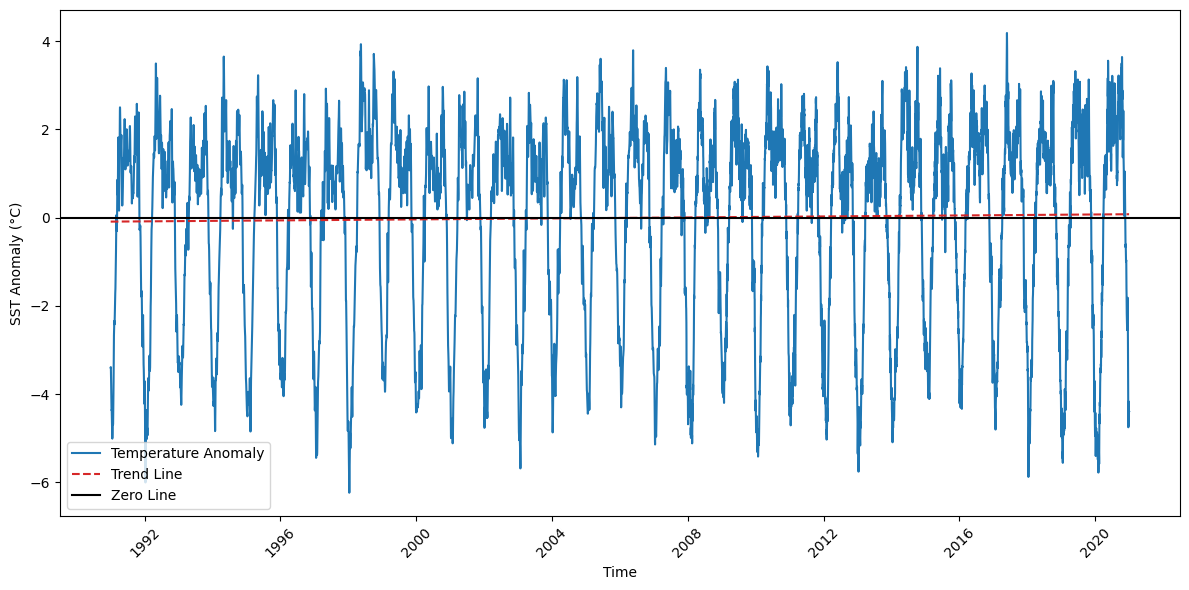

In [ ]:
temperature_anomaly = temperature - temperature.mean(dim='valid_time')
# Extract the anomalies for the chosen lat-lon point
temperature_anomaly_timeseries = temperature_anomaly.sel(valid_time=time_filtered, latitude=ds.latitude[lat_idx], longitude=ds.longitude[lon_idx])

time_numeric = np.arange(len(temperature_anomaly_timeseries.valid_time))
trend_coeffs = np.polyfit(time_numeric, temperature_anomaly_timeseries, 1)
trend_line = np.polyval(trend_coeffs, time_numeric)

total_anomaly = float(temperature_anomaly_timeseries.sum().values)
print(f"Total SST Anomaly (°C) from {str(time_filtered[0].values)[:10]} to {str(time_filtered[-1].values)[:10]}: {total_anomaly:.4f} °C")

# Plot Temperature Anomaly Time Series
plt.figure(figsize=(12, 6))
plt.plot(temperature_anomaly_timeseries.valid_time, temperature_anomaly_timeseries, label='Temperature Anomaly', color='tab:blue')
plt.plot(temperature_anomaly_timeseries.valid_time, trend_line, label='Trend Line', color='tab:red', linestyle='--')
plt.axhline(0, color='black', linestyle='-', label='Zero Line')
plt.xlabel('Time')
plt.ylabel('SST Anomaly (°C)')
plt.grid(False)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Get the temperature anomaly values
temperature_anomaly_values = temperature_anomaly_timeseries.values

# Calculate the zero/mean value
mean_anomaly = np.mean(temperature_anomaly_values)

# Calculate the range of anomalies (difference between max and min values)
anomaly_range = np.ptp(temperature_anomaly_values)

# Calculate the total change (the difference between the last and first anomaly values)
total_change = temperature_anomaly_values[-1] - temperature_anomaly_values[0]

# Print the results
print(f"Mean Anomaly (Zero value): {mean_anomaly:.2f} °C")
print(f"Anomaly Range: {anomaly_range:.2f} °C")
print(f"Total Change in Temperature: {total_change:.2f} °C")

Mean Anomaly (Zero value): -0.01 °C
Anomaly Range: 10.42 °C
Total Change in Temperature: -0.99 °C


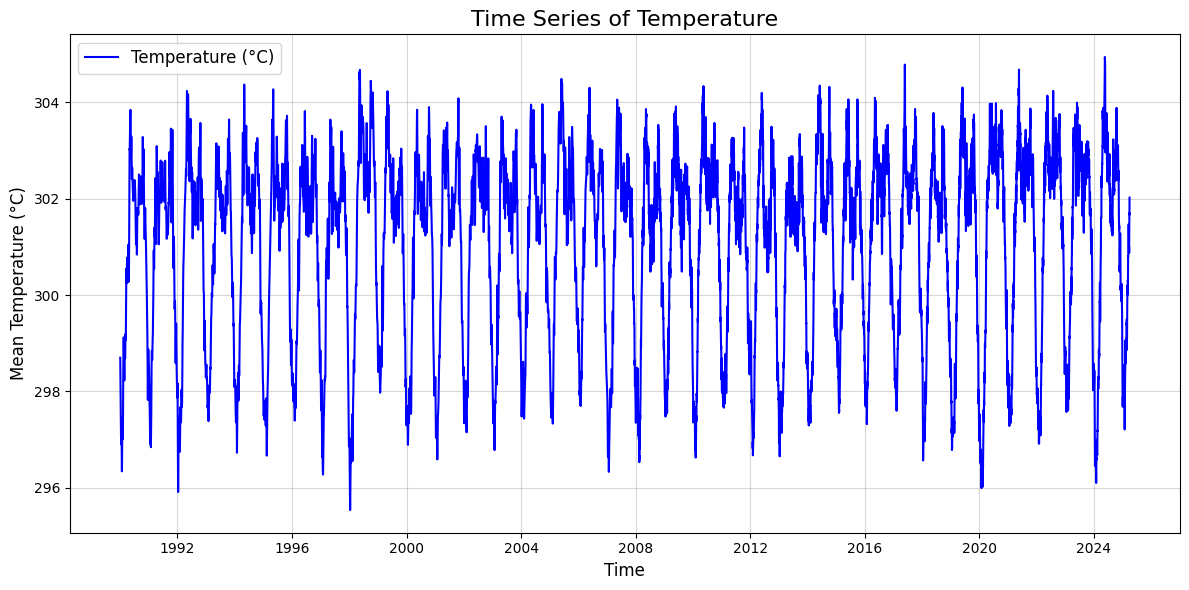

In [ ]:
temperature_mean = temperature.mean(dim=['latitude', 'longitude'])

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(temperature_mean['valid_time'], temperature_mean, label='Temperature (°C)', color='blue')

# Add labels and title
plt.title('Time Series of Temperature', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Mean Temperature (°C)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

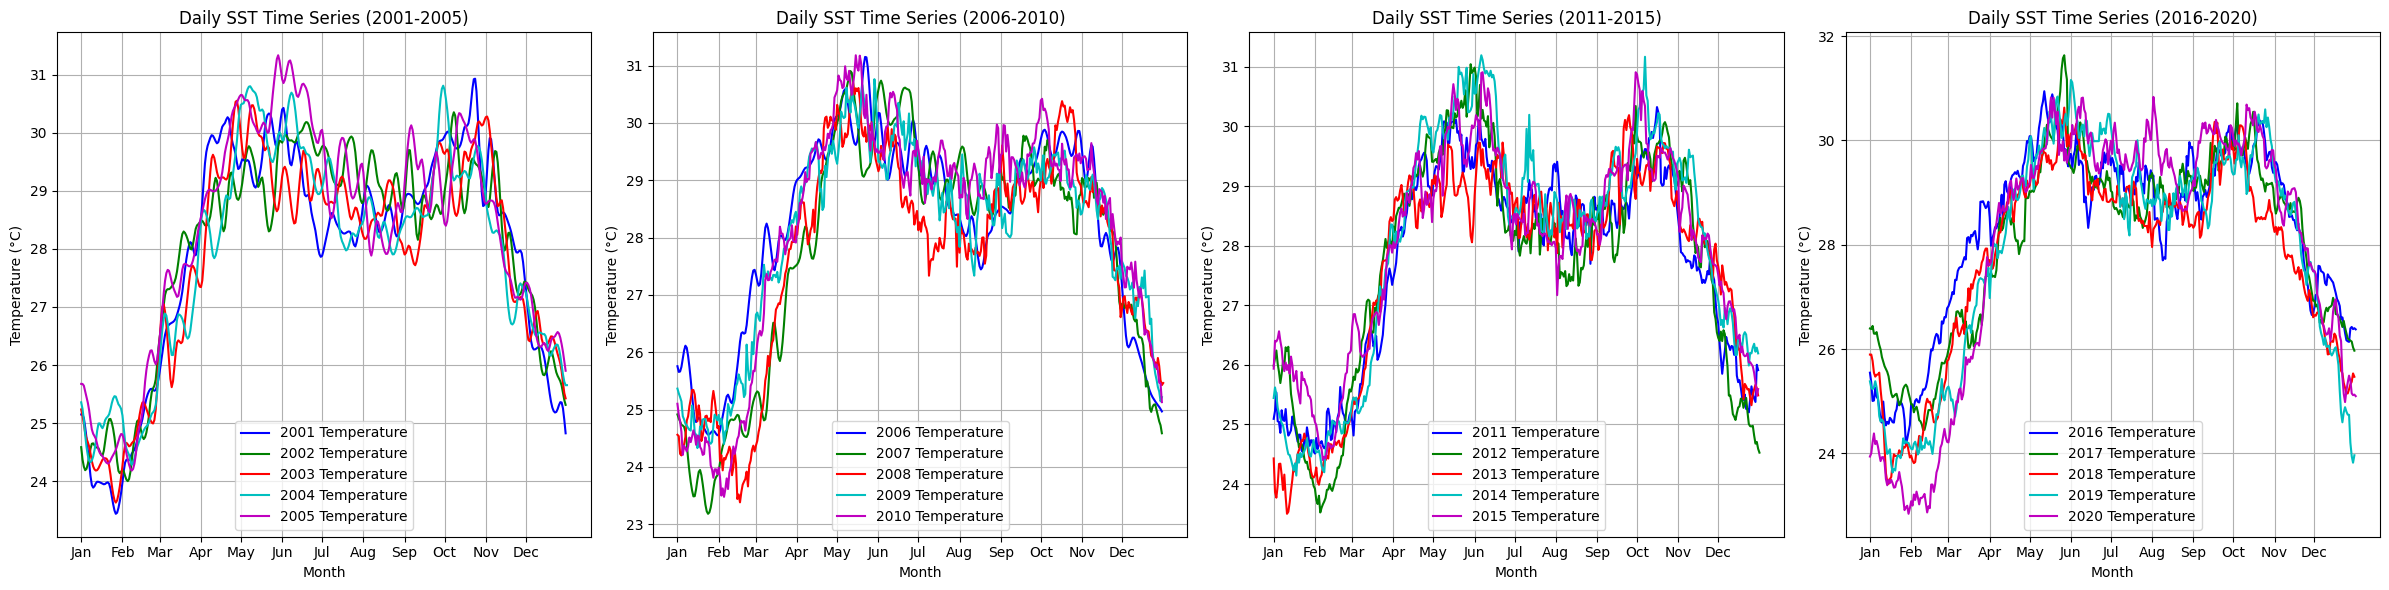

In [ ]:
temperature = ds['sst'].mean(dim=['latitude', 'longitude']) - 273.15

# Function to process data for specific year ranges
def get_yearly_data(start_year, end_year):
    yearly_data = []
    for year in range(start_year, end_year + 1):
        temp = temperature.sel(valid_time=slice(f"{year}-01-01", f"{year}-12-31"))
        yearly_data.append(temp)
    return yearly_data

# Define year ranges and process data
ranges = [(2001, 2005), (2006, 2010), (2011, 2015), (2016, 2020)]
all_data = [get_yearly_data(start, end) for start, end in ranges]

# Colors and labels
colors = ['b', 'g', 'r', 'c', 'm']
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
days_in_month = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

# Create the figure with subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))  # 2x2 grid of subplots
axes = axes.flatten()  # Flatten to easily index subplots

for i, (year_range, yearly_data) in enumerate(zip(ranges, all_data)):
    ax = axes[i]
    for temp, color, year in zip(yearly_data, colors, range(year_range[0], year_range[1] + 1)):
        day_of_year = pd.to_datetime(temp['valid_time'].values).day_of_year
        ax.plot(day_of_year, temp, color=color, label=f'{year} Temperature')

    # Add labels, grid, legend, and title
    ax.set_xlabel("Month")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title(f"Daily SST Time Series ({year_range[0]}-{year_range[1]})")
    ax.set_xticks(days_in_month)
    ax.set_xticklabels(month_names)
    ax.grid(True)
    ax.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
sst = ds['sst'] - 273.15

seasons = {
    'Winter': [11, 12, 1],
    'Premonsoon': [2, 3, 4],
    'Monsoon': [5, 6, 7],
    'PostMonsoon': [8, 9, 10],
}

def calculate_anomalies(data, months, start_year, end_year):
    # Flatten across lat/lon
    data_mean = data.mean(dim=['latitude', 'longitude'])

    # Convert time to pandas datetime index
    time = pd.to_datetime(data_mean['valid_time'].values)
    df = pd.DataFrame({'time': time, 'value': data_mean.values})
    df['month'] = df['time'].dt.month
    df['year'] = df['time'].dt.year

    # Filter for the selected years and months
    df = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
    if 1 in months and 12 in months:  # Handle seasons crossing years like Winter
        df = df[(df['month'].isin(months)) | ((df['month'] == 1) & (df['year'] > start_year))]
    else:
        df = df[df['month'].isin(months)]

    # Group by year and take mean
    seasonal_means = df.groupby('year')['value'].mean()

    # Calculate anomalies
    climatology = seasonal_means.mean()
    anomalies = seasonal_means - climatology

    # Return as xarray for consistency
    return xr.DataArray(anomalies.values, coords=[anomalies.index], dims=['year'])

start_year, end_year = 2001, 2020
seasonal_anomalies = {
    season: calculate_anomalies(sst, months, start_year, end_year)
    for season, months in seasons.items()
}

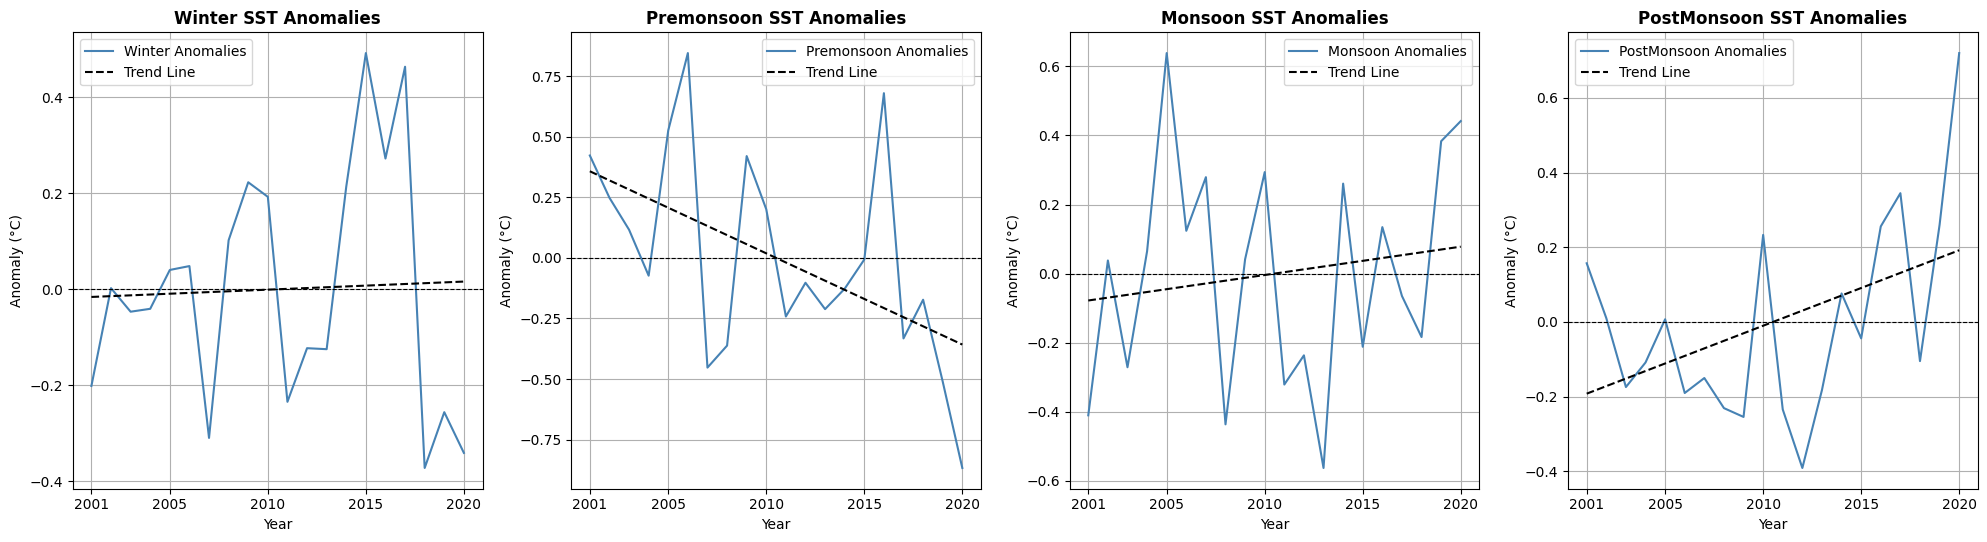

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 6))

for ax, (season, anomalies) in zip(axs.flat, seasonal_anomalies.items()):
    years = anomalies['year'].values
    values = anomalies.values

    ax.plot(years, values, label=f'{season} Anomalies', color='steelblue')

    # Add trend line
    slope, intercept, r_value, p_value, std_err = linregress(years, values)
    trend_line = slope * years + intercept
    ax.plot(years, trend_line, color='black', linestyle='--', label='Trend Line')

    # Custom ticks
    selected_years = [2001, 2005, 2010, 2015, 2020]
    ax.set_xticks(selected_years)
    ax.set_xticklabels(selected_years)

    # Labels and title
    ax.set_title(f'{season} SST Anomalies', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Anomaly (°C)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()